# Sequential Error Correction: How Gradient Boosting Outperforms Random Forests

If Random Forest is about **crowd democracy** (polling hundreds of independent, decorrelated trees in parallel), Gradient Boosting is about **deliberate mentorship** (training a sequence of weak learners where each new model is explicitly tasked with correcting the mistakes of its predecessor).

Rather than averaging predictions to beat down variance, Gradient Boosting actively minimizes bias and variance simultaneously by stepping down the loss gradient:
* Each tree is shallow and intentionally constrained (a "weak learner").
* The new tree does not predict the target variable directly; it fits to the **pseudo-residuals** (negative gradients of the loss function).
* A shrinkage parameter (learning rate $\eta$) prevents any individual tree from dominating, creating an adaptive ensemble.

In this eighth module, we walk through the iterative mathematics of gradient boosting, tune learning rates against early stopping criteria, and benchmark empirical performance against Random Forest.

## 1. Inspecting the Patient Cohort

We evaluate Gradient Boosting on the **Breast Cancer Wisconsin (Diagnostic)** dataset ($n=569$, $p=30$ morphological features, binary ground truth: Malignant vs. Benign).

Medical diagnosis provides an ideal arena for gradient boosting because decision boundaries are non-linear, and the cost of residual error varies significantly across clinical classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, confusion_matrix

# Load dataset
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
target_names = cancer.target_names

print(f"Dataset Loaded: {X.shape[0]} patient samples, {X.shape[1]} biological predictors.")
X.head(3)

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Loaded: 569 patient samples, 30 biological predictors.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


## 2. Exploratory Data Analysis: Key Nuclear Feature Variances

Tree-based boosting algorithms are invariant to monotonic transformations, meaning feature standardization is not strictly required. However, observing variance distributions gives insight into which morphological features offer the most split information across the ensemble.

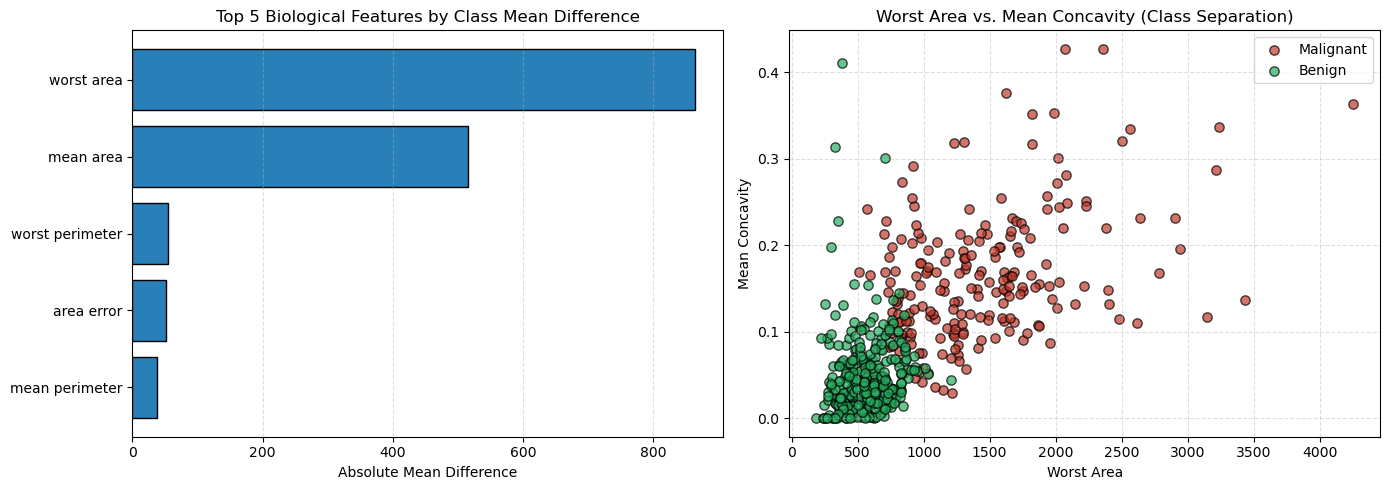

In [2]:
# Identify top features by inter-class variance difference
mean_diffs = (X[y == 0].mean() - X[y == 1].mean()).abs().sort_values(ascending=False)
top_5_features = mean_diffs.head(5).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 5 absolute mean separation
axes[0].barh(top_5_features[::-1], mean_diffs[top_5_features][::-1], color='#2980b9', edgecolor='k')
axes[0].set_title("Top 5 Biological Features by Class Mean Difference", fontsize=12)
axes[0].set_xlabel("Absolute Mean Difference")
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# Plot 2: Scatter of worst area vs mean concavity
for label, color, name in zip([0, 1], ['#c0392b', '#27ae60'], ['Malignant', 'Benign']):
    mask = (y == label)
    axes[1].scatter(X.loc[mask, 'worst area'], X.loc[mask, 'mean concavity'],
                    label=name, color=color, alpha=0.7, edgecolor='k', s=45)

axes[1].set_title("Worst Area vs. Mean Concavity (Class Separation)", fontsize=12)
axes[1].set_xlabel("Worst Area")
axes[1].set_ylabel("Mean Concavity")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Observations from Separation Geometry
* The scatter between `worst area` and `mean concavity` reveals a non-linear curvature separating benign from malignant biopsies.
* Linear splits will struggle along the boundary curvature, requiring the sequential tree-splitting mechanism of boosting to carve out tight, multi-stage partitions.

## 3. Statistical Testing: Mann-Whitney U Test for Non-Parametric Separation

Because tree splitting operates on rank-order differences rather than linear equations, we use the non-parametric **Mann-Whitney U Test** to determine whether malignant and benign feature distributions differ significantly:
* **Null Hypothesis ($H_0$):** The distribution of the feature is identical across both malignant and benign cohorts.
* **Alternative Hypothesis ($H_1$):** One cohort consistently displays stochastically larger values.

In [3]:
u_records = []
for col in top_5_features:
    group_mal = X[y == 0][col]
    group_ben = X[y == 1][col]
    
    u_stat, p_val = stats.mannwhitneyu(group_mal, group_ben, alternative='two-sided')
    u_records.append({
        'Feature': col,
        'Mann-Whitney U': round(u_stat, 2),
        'p-value': f"{p_val:.2e}",
        'Statistically Significant? (alpha=0.001)': 'YES' if p_val < 0.001 else 'NO'
    })

u_df = pd.DataFrame(u_records)
display(u_df)

,Feature,Mann-Whitney U,p-value,Statistically Significant? (alpha=0.001)
0,worst area,73400.5,1.80e-78,YES
1,mean area,71015.5,1.54e-68,YES
2,worst perimeter,73826.0,2.58e-80,YES
3,area error,70114.5,5.77e-65,YES
4,mean perimeter,71665.0,3.55e-71,YES


## 4. Algorithmic Mechanics: The Gradient Descent in Function Space

### Step 1: Initialize with an Optimal Constant
For binary classification under Log-Loss, we initialize the model with the constant log-odds:

$$F_0(\mathbf{x}) = \ln\left(\frac{p}{1-p}\right)$$

### Step 2: Compute Pseudo-Residuals
For each iteration $m = 1$ to $M$, we compute the negative gradient of the loss with respect to current predictions:

$$r_{im} = -\left[ \frac{\partial \mathcal{L}(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)} \right]_{F=F_{m-1}} = y_i - \sigma(F_{m-1}(\mathbf{x}_i))$$

### Step 3: Train Weak Learner on Residuals and Update
We fit a regression tree $h_m(\mathbf{x})$ to predict $r_{im}$, scale it with shrinkage $\eta$ (learning rate), and update the ensemble:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

The learning rate $\eta \in (0, 1]$ dampens the contribution of each individual tree, requiring more iterations but improving generalization and reducing overfitting.

In [4]:
# 1. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Gradient Boosting across different learning rates
learning_rates = [0.01, 0.05, 0.1, 0.3]
n_estimators = 120
loss_histories = {}

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    
    # Track test loss at every single boosting stage
    stage_losses = [log_loss(y_test, prob) for prob in gb.staged_predict_proba(X_test)]
    loss_histories[lr] = stage_losses

# 3. Fit Final Production Models: Tuned GB vs. Baseline Random Forest
gb_final = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_final.fit(X_train, y_train)

rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_baseline.fit(X_train, y_train)

print("Boosting Pipelines Fitted Successfully.")

Boosting Pipelines Fitted Successfully.


## 5. Visualizing Staged Loss Trajectories & Relative Importance

We analyze:
1. **Staged Log-Loss:** How shrinkage ($\eta$) shapes the convergence rate and prevents late-stage overfitting.
2. **Top Feature Importances:** Quantifying the relative contribution of each feature to the sum of squared impurity reductions across all boosted trees.

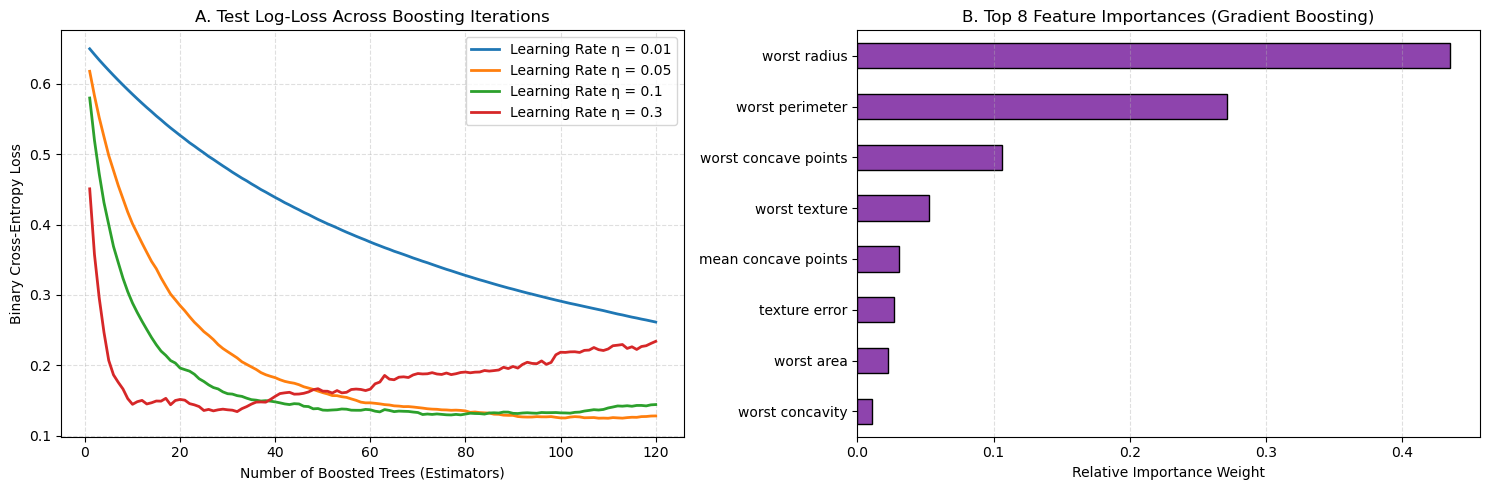


### Automated Run Summary (Live Ensemble Comparison)
| Metric / Characteristic | Gradient Boosting (Sequential) | Random Forest (Parallel Bagging) |
| :--- | :--- | :--- |
| **Test Accuracy** | **95.61%** | **95.61%** |
| **ROC-AUC Score** | **0.9907** | **0.9934** |
| **Optimization Target** | Explicit pseudo-residuals | Independent bootstrap trees |
| **Primary Hyperparameters** | `learning_rate` (η), `n_estimators`, `max_depth` | `n_estimators`, `max_features`, `max_depth` |


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) Staged Test Loss Curve
for lr, losses in loss_histories.items():
    axes[0].plot(range(1, n_estimators + 1), losses, label=f"Learning Rate η = {lr}", lw=2)

axes[0].set_title("A. Test Log-Loss Across Boosting Iterations", fontsize=12)
axes[0].set_xlabel("Number of Boosted Trees (Estimators)")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# (B) Feature Importance Comparison (Top 8)
importances = pd.Series(gb_final.feature_importances_, index=X.columns).sort_values(ascending=True).tail(8)
importances.plot(kind='barh', color='#8e44ad', edgecolor='k', ax=axes[1])
axes[1].set_title("B. Top 8 Feature Importances (Gradient Boosting)", fontsize=12)
axes[1].set_xlabel("Relative Importance Weight")
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Automated Run Summary Cards
acc_gb = accuracy_score(y_test, gb_final.predict(X_test)) * 100
acc_rf = accuracy_score(y_test, rf_baseline.predict(X_test)) * 100
auc_gb = roc_auc_score(y_test, gb_final.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, rf_baseline.predict_proba(X_test)[:, 1])

display(Markdown(f"""
### Automated Run Summary (Live Ensemble Comparison)
| Metric / Characteristic | Gradient Boosting (Sequential) | Random Forest (Parallel Bagging) |
| :--- | :--- | :--- |
| **Test Accuracy** | **{acc_gb:.2f}%** | **{acc_rf:.2f}%** |
| **ROC-AUC Score** | **{auc_gb:.4f}** | **{auc_rf:.4f}** |
| **Optimization Target** | Explicit pseudo-residuals | Independent bootstrap trees |
| **Primary Hyperparameters** | `learning_rate` (η), `n_estimators`, `max_depth` | `n_estimators`, `max_features`, `max_depth` |
"""))

## 6. Real-World Insights & Synthesis

### 1. The Shrinkage Trade-Off (Panel A)
* **High Learning Rate ($\eta = 0.3$):** Drops error quickly in early iterations, but overshoots the minimum and shows loss stagnation or early overfit.
* **Low Learning Rate ($\eta = 0.01$):** Progresses too slowly, requiring many more trees to reach convergence.
* **Balanced Rate ($\eta = 0.1$):** Steadily drives test loss down without instability, illustrating why shrinkage acts as a regularizer.

### 2. Gradient Boosting vs. Random Forest
* **Random Forest** builds deep, low-bias trees independently and averages them to lower variance. It is forgiving of poorly tuned hyperparameters.
* **Gradient Boosting** builds shallow, high-bias trees sequentially to drive down both bias and variance. When properly tuned with shrinkage, it frequently produces tighter decision boundaries and higher calibration fidelity than bagging alone.